In [ ]:
%display latex
%pip install networkx

Study Group Night 1
===

My part of the study group table was trying to walk through/reconstruct the example graph that Dr. Eisenträeger used in her lecture on day 1.  (This example occurs around 31:30 in the presentation stream; it is not in the LaTeX notes.)

First, some preliminary display code:

In [90]:
import networkx as nx

def to_multidigraph(adj_map):
    G = nx.MultiDiGraph()
    for j in adj_map:
        G.add_node(j)

    for j, n_dict in adj_map.items():
        for n_j, n_list in n_dict.items():
            for _ in n_list:
                G.add_edge(j, n_j)

    return G

In [119]:
from itertools import accumulate
# based heavily on https://networkx.org/documentation/stable/auto_examples/drawing/plot_multigraphs.html
def draw_labeled_multigraph(G, ax=None):
    connectionstyle = [f"arc3,rad={r}" for r in accumulate([0.15] * 4)]

    pos = nx.shell_layout(G)
    nx.draw_networkx_nodes(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10, font_color='white', ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color="grey", connectionstyle=connectionstyle, ax=ax
    )

Simple/Naive approach
---

The naive approach that we first were working through was to attempt to construct all elliptic curves, get their J-invariants, and from there determine if the curves were supersingular.  In this manner, we could at least get the *nodes* of the graph.  This doesn't rely much on Sage's built-in abilities, but it works from "first principles."  This implementation uses the condition in Theorem 4.1(a) from Silverman *The Arithmetic of Elliptic Curves* (2nd ed, page 148); it just *assumes* that the roots are distinct, though --- I don't have a check for that:

In [121]:
from itertools import product

def is_supersingular(p, a, b):
    k = GF(p)
    R.<x> = k['x']
    f = x^3 + a*x + b
    return (f^((p-1)/2)).list()[p-1] == 0

def j_invariant(p, a, b):
    return (1728 * (4*a^3)/(4*a^3 + 27*b^2)) % p

def brute_force_node_construction(p):
    supersingular_invariants = set()
    for a, b in product(range(p), range(p)):
        if a == 0 and b == 0:
            continue

        if is_supersingular(p, a, b):
            supersingular_invariants.add(j_invariant(p, a, b))

    return supersingular_invariants

print(brute_force_node_construction(31))

{2, 4, 23}


This works --- it returns the three j-invariants in the graph that Dr. Eisenträeger used, but there are some obvious issues.  Namely: it is slow! This takes enumerates $p^2$ curves, but the number of supersingular curves is almost exactly $p/12$. (See Theorem 4.1(c) in Silverman, the numeric value of which is computed below.) Thus, there is a lot of wasted work.


In [135]:
def number_of_supersingular_curves(p):
    adjustment = {
        1 : 0,
        5 : 1,
        7 : 1,
        11: 2,
    }[p%12]

    return floor(p/12) + adjustment

number_of_supersingular_curves(31)

3

Further, it's also a quite brittle approach that doesn't fully make use of the CAS.

Fortunately, there is a better way!

Modular Polynomial Approach
---

Supposing we *have* a starting node in the graph, we can find its neighbors via the roots of the [Modular Polynomial](https://doc.sagemath.org/html/en/reference/arithmetic_curves/sage/schemes/elliptic_curves/mod_poly.html) of level $\ell$ (our case is $\ell=2$).  The roots of this (multivariate) polynomial are the pairs of j-invariants that have edges between them in the digraph, and the multiplicty of the roots corresponds to the number of $\ell$-isogenies between the pair (i.e. the number of edges in the digraph).

This gives rise to a "nice" approach to constructing the graph: given a starting node you know is supersingular, run a graph traversal (e.g. breadth-first search), computing neighbors with the level $\ell$ modular polynomial at each step.  

However, we do need to know a starting node.  Fortunately, for primes $p \equiv 3 \pmod{4}$, elliptic curves with j-invariant 1728 are supersingular.  So, for all of those primes, we can use 1728 as our starting node.  (And, since $p=31 \equiv 3\pmod{4}$, it works for our example graph we're trying to reconstruct.). We can also use the starting j-invariant $0$ for primes $p\equiv 2 \pmod{3}$.

In [122]:
def get_adjacency_map(p, l=2, start_with=1728):
    if start_with == 1728 and p % 4 != 3:
        raise ValueError(f"p % 4 != 3, but 1728 is not supersingular in this case")
    if start_with == 0 and p % 3 != 2:
        raise ValueError(f"p % 3 != 2, but 0 is not supersingular in this case")
    
    k = GF(p)
    adj_map = {}
    start_node = k(start_with)
    to_visit = [start_node]
    
    while len(to_visit) > 0:
        j = to_visit.pop()
        if j in adj_map:
            continue
            
        poly = classical_modular_polynomial(l, j)
        neighbors = poly.roots()
    
        adj_map[j] = {}
        for (n_j, n_mult) in neighbors:
            adj_map[j][n_j] = list(range(n_mult))
            to_visit.append(n_j)
    return adj_map

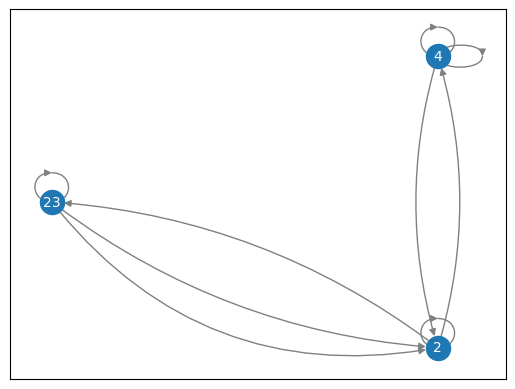

In [136]:
m = get_adjacency_map(31, 2)
G = to_multidigraph(m)
draw_labeled_multigraph(G)

This graph may be a bit ugly (it's just using Sage's built-in graph display), but it correctly picks up on the two self-loops on $j=4$, and the correct orientation of the edges between $j=2$ and $j=23$.

However, there are *still* some problems with this.  Namely, while this method is quite "clean," it does not tell us the actual isogenies between the j-invariants --- only that there *is* an isogeny.

Torsion Point Approach
---
We may compute the isogenies explictly by considering the $\ell$-torsion points of each curve, finding which create cyclic groups of order $\ell$, and then constructing the isongeny using those points as the kernel of the isogeny.  The following procedure uses the Sage function `EllipticCurve.isogeny(P)`, which forms that isogeny directly.  If we were to do this manually, we'd use Vélu's formulas... but we fortunately can have Sage do so in this instance.

In [137]:
from itertools import groupby

def get_isogenies_from(p, j, l=2):
    k = GF(p)
    E = EllipticCurve(k.algebraic_closure(), j=j)
    torsion_points = E(0).division_points(l)

    cyclic_points = [P for P in torsion_points if P.order() == l]
    isogenies = [E.isogeny(P) for P in cyclic_points]

    return { j: list(phis) for j, phis in groupby(isogenies, key=lambda phi: phi.codomain().j_invariant()) }


In [138]:
for j, phi_list in get_isogenies_from(31, 2).items():
    print(f"Isogenies to j={j}")
    for phi in phi_list:
        pretty_print(phi.rational_maps())

Isogenies to j=4


((x^2 + 21*x + 23)/(x + 21), (x^2*y + 11*x*y + 15*y)/(x^2 + 11*x + 7))

Isogenies to j=23


((x^2 + 9*x + 28)/(x + 9), (x^2*y + 18*x*y + 22*y)/(x^2 + 18*x + 19))

Isogenies to j=2


((x^2 + x + 5)/(x + 1), (x^2*y + 2*x*y + 27*y)/(x^2 + 2*x + 1))

We could use the above as the mechanism for finding neighbors in the BFS algorithm, also enabling us to annotate the graph with the rational maps for each isogeny.  This is done below:

In [140]:
def get_adjacency_map_torsion(p, l=2, start_with=1728):
    if start_with == 1728 and p % 4 != 3:
        raise ValueError(f"p % 4 != 3, but 1728 is not supersingular in this case")
    if start_with == 0 and p % 3 != 2:
        raise ValueError(f"p % 3 != 2, but 0 is not supersingular in this case")
    
    k = GF(p)
    adj_map = {}
    start_node = k(start_with)
    to_visit = [start_node]
    
    while len(to_visit) > 0:
        j = to_visit.pop()
        if j in adj_map:
            continue
            
        neighbors = [(n_j, len(phis)) for n_j, phis in get_isogenies_from(p, j).items()]
        adj_map[j] = {}
        for (n_j, n_mult) in neighbors:
            adj_map[j][n_j] = list(range(n_mult))
            to_visit.append(n_j)
    return adj_map

This obviously agrees with the original method:

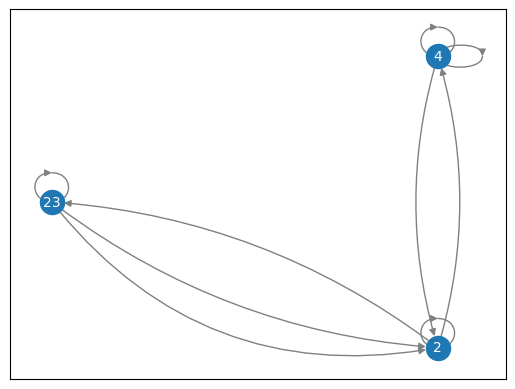

In [145]:
m = get_adjacency_map_torsion(31, 2)
G = to_multidigraph(m)
draw_labeled_multigraph(G)

But, for variety's sake, I'll include a larger prime just to see what may be computed:

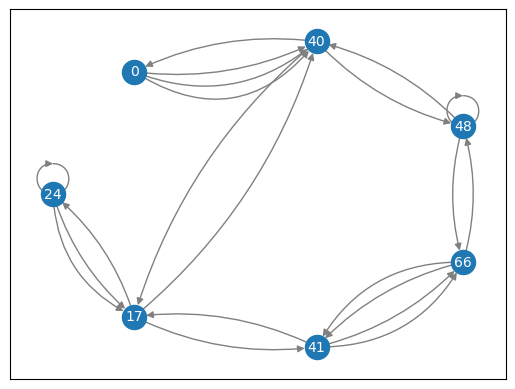

In [146]:
m = get_adjacency_map_torsion(71, 2)
G = to_multidigraph(m)
draw_labeled_multigraph(G)

I should note that there are tradeoffs between these methods --- while the torsion subgroup method does give us the isogenies directly, it also takes longer:

In [143]:
%timeit get_adjacency_map_torsion(71, 2)

1.15 s ± 17.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [144]:
%timeit get_adjacency_map(71, 2)

1.95 ms ± 25 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


I expect that this is because the modular polynomials are cached/looked up in a database within sage.